In [5]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

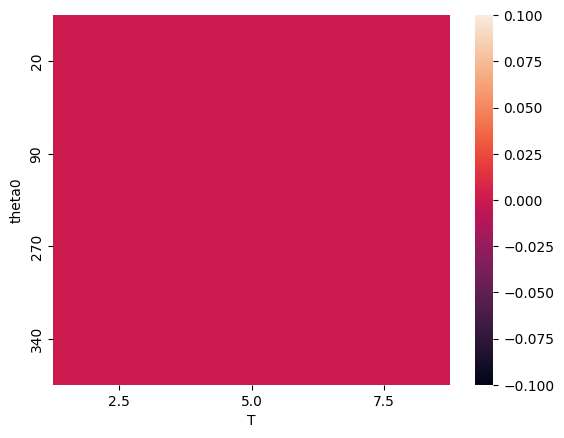

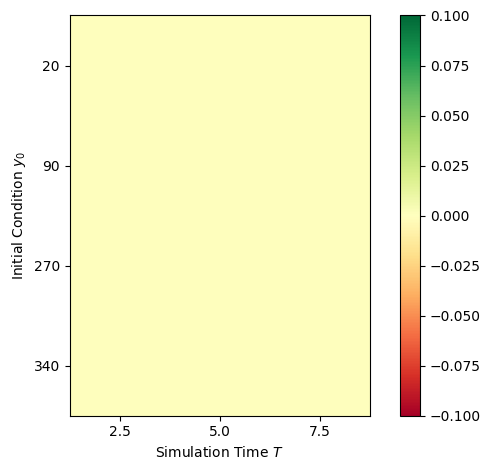

In [ ]:
results = pd.read_csv("results_no_reg.csv")


table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["theta0"],
                        columns=["T"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns, rotation=0)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $theta_0$')


plt.tight_layout()
plt.show()

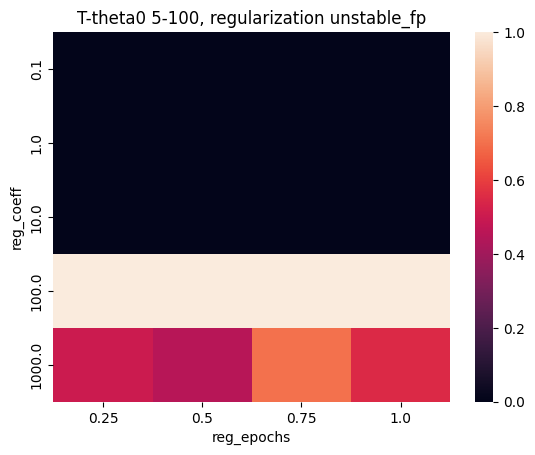

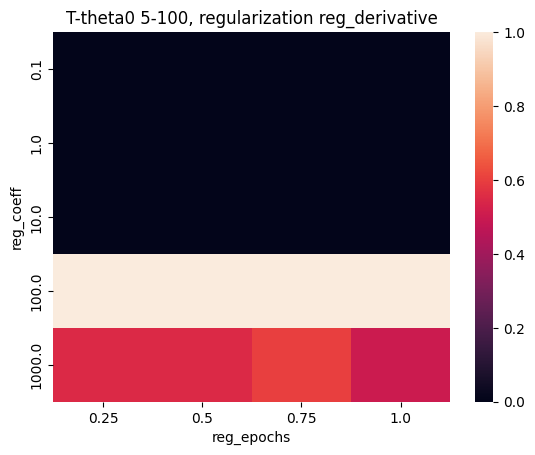

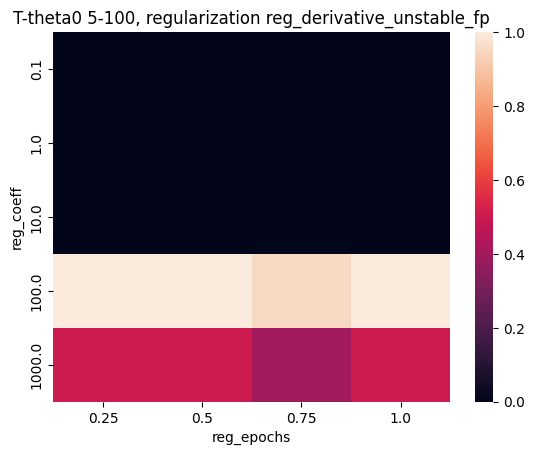

In [6]:
results = pd.read_csv("results_linear_decay.csv")

results["T-theta0"] = results["T"].astype(str) + "-" + results["theta0"].astype(str)

for settings in results["T-theta0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-theta0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        sns.heatmap(table)
        plt.title(f"T-theta0 {settings}, regularization {regularization}")
        plt.show()